In [5]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Not running in Google Colab — setup skipped.
Python version: 3.12.12


## Imports & Version Check

Run this cell once before starting the assignment to import packages.

In [6]:
import numpy as np
import scipy
import matplotlib
import pandas as pd
import plotly

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pd.__version__)
print("plotly:", plotly.__version__)

import matplotlib.pyplot as plt
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


## Define Structure

In [ ]:
# ------------------------------------------------------------
# In-Class Structure
# ------------------------------------------------------------

nodes = {
    1: (0.0, 0.0),
    2: (1.0, 3.0),
    3: (3.0, 0.0),
    4: (5.0, 4.0),
}
nodes_loads = {
    1: (-10.0, -10.0),
    2: (0.0, 0.0),
    3: (0.0, 0.0),
    4: (0.0, 0.0),
}
# Branches defined by their start and end nodes (1-indexed)
elements = {
    1: (1, 3),
    2: (1, 2),
    3: (2, 3),
    4: (2, 4),
    5: (3, 4),
}
fixed_nodes = [3, 4] #1-indexed
free_nodes = [1, 2] #1-indexed


# ------------------------------------------------------------
# Specified Force Densities
# ------------------------------------------------------------
q = np.array([3.0, 3.0, 2, 2.5, 0.5])

In [ ]:
# # ------------------------------------------------------------
# # Another Structure
# # ------------------------------------------------------------

# nodes = {
#     1: (-2.0,  0.0),
#     2: ( 0.0, -2.0),
#     3: ( 2.0,  0.0),
#     4: ( 0.0,  2.0),
#     5: ( 0.0,  0.0),
#     6: (-3.0,  0.0),
#     7: ( 0.0, -3.0),
#     8: ( 3.0,  0.0),
#     9: ( 0.0,  3.0),
#     # 10: (-2.0, 1.0,
# }

# nodes_loads = {
#     1: (0.0, 0.0),
#     2: (0.0, 0.0),
#     3: (0.0, 0.0),
#     4: (0.0, 0.0),
#     5: (0.0, 0.0),
#     6: (0.0, 0.0),
#     7: (0.0, 0.0),
#     8: (0.0, 0.0),
#     9: (0.0, 0.0),
#     # 10: (0.0, 0.0),
# }

# # Branches defined by their start and end nodes (1-indexed)
# elements = {
#     1: (1, 6),
#     2: (2, 7),
#     3: (3, 8),
#     4: (4, 9),
#     5: (1, 4),
#     6: (1, 2),
#     7: (2, 3),
#     8: (3, 4),
#     9: (4, 5),
#     10: (1, 5),
#     11: (2, 5),
#     12: (3, 5),
#     # 13: (1, 10),
#     # 14: (2, 10),
#     # 15: (3, 10),
# }

# fixed_nodes = [6, 7, 8, 9]   # 1-indexed
# free_nodes = [1, 2, 3, 4, 5] # 1-indexed


# # ------------------------------------------------------------
# # Specified Force Densities
# # ------------------------------------------------------------
# q = np.array([
#     1.0, 1.0, 1.0, 1.0,
#     1.0, 1.0, 1.0, 1.0,
#     1.0, 1.0, 1.0, 1.0,
#     # 0.0, 0.0, 0.0,
# ])

In [9]:
# ------------------------------------------------------------
# Applied Loads
# ------------------------------------------------------------

def create_node_force_vectors(nodes_loads, free_nodes):

    p_x = np.array([nodes_loads[node][0] for node in free_nodes], dtype=float).reshape(-1, 1)
    p_y = np.array([nodes_loads[node][1] for node in free_nodes], dtype=float).reshape(-1, 1)

    return p_x, p_y

p_x, p_y = create_node_force_vectors(nodes_loads, free_nodes)

## Branch-Node Matrix

In [10]:
# ------------------------------------------------------------
# Build branch-node matrix
# ------------------------------------------------------------
def build_full_branch_node_matrix(elements):
    n_nodes = max(max(start, end) for start, end in elements.values())
    m = len(elements)

    C_s = np.zeros((m, n_nodes), dtype=int)

    for r, (start, end) in enumerate(elements.values()):
        C_s[r, start - 1] = 1
        C_s[r, end - 1] = -1

    return C_s

C_s = build_full_branch_node_matrix(elements)
print(C_s)

[[ 1  0  0  0  0 -1  0  0  0]
 [ 0  1  0  0  0  0 -1  0  0]
 [ 0  0  1  0  0  0  0 -1  0]
 [ 0  0  0  1  0  0  0  0 -1]
 [ 1  0  0 -1  0  0  0  0  0]
 [ 1 -1  0  0  0  0  0  0  0]
 [ 0  1 -1  0  0  0  0  0  0]
 [ 0  0  1 -1  0  0  0  0  0]
 [ 0  0  0  1 -1  0  0  0  0]
 [ 1  0  0  0 -1  0  0  0  0]
 [ 0  1  0  0 -1  0  0  0  0]
 [ 0  0  1  0 -1  0  0  0  0]]


In [11]:
# ------------------------------------------------------------
# Build partitioned branch-node matrices
# ------------------------------------------------------------
def partition_branch_node_matrix(C_s, free_nodes):
    free_idx = [node - 1 for node in free_nodes]
    fixed_idx = [j for j in range(C_s.shape[1]) if j not in free_idx]

    C = C_s[:, free_idx]
    C_f = C_s[:, fixed_idx]

    return C, C_f

C, C_f = partition_branch_node_matrix(C_s, free_nodes)
print(C)
print(C_f)

[[ 1  0  0  0  0]
 [ 0  1  0  0  0]
 [ 0  0  1  0  0]
 [ 0  0  0  1  0]
 [ 1  0  0 -1  0]
 [ 1 -1  0  0  0]
 [ 0  1 -1  0  0]
 [ 0  0  1 -1  0]
 [ 0  0  0  1 -1]
 [ 1  0  0  0 -1]
 [ 0  1  0  0 -1]
 [ 0  0  1  0 -1]]
[[-1  0  0  0]
 [ 0 -1  0  0]
 [ 0  0 -1  0]
 [ 0  0  0 -1]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]]


## Geometry Setup

In [12]:
# ------------------------------------------------------------
# Coordinate vectors
# ------------------------------------------------------------
def build_coordinate_vectors(nodes, free_nodes, fixed_nodes):
    x = np.array([nodes[node][0] for node in free_nodes], dtype=float).reshape(-1, 1)
    y = np.array([nodes[node][1] for node in free_nodes], dtype=float).reshape(-1, 1)
    x_f = np.array([nodes[node][0] for node in fixed_nodes], dtype=float).reshape(-1, 1)
    y_f = np.array([nodes[node][1] for node in fixed_nodes], dtype=float).reshape(-1, 1)
    return x, y, x_f, y_f

x, y, x_f, y_f = build_coordinate_vectors(nodes, free_nodes, fixed_nodes)
print(x)
print(x_f)


[[-2.]
 [ 0.]
 [ 2.]
 [ 0.]
 [ 0.]]
[[-3.]
 [ 0.]
 [ 3.]
 [ 0.]]


In [13]:
# ------------------------------------------------------------
# Branch coordinate differences
# ------------------------------------------------------------
def build_branch_coordinate_differences(C, C_f, x, y, x_f, y_f):
    u = C @ x + C_f @ x_f
    v = C @ y + C_f @ y_f

    return u, v

u, v = build_branch_coordinate_differences(C, C_f, x, y, x_f, y_f)
print("\nu = Δx =\n", u)
print("\nv = Δy =\n", v)


u = Δx =
 [[ 1.]
 [ 0.]
 [-1.]
 [ 0.]
 [-2.]
 [-2.]
 [-2.]
 [ 2.]
 [ 0.]
 [-2.]
 [ 0.]
 [ 2.]]

v = Δy =
 [[ 0.]
 [ 1.]
 [ 0.]
 [-1.]
 [-2.]
 [ 2.]
 [-2.]
 [-2.]
 [ 2.]
 [ 0.]
 [-2.]
 [ 0.]]


In [14]:
# ------------------------------------------------------------
# Branch lengths
# ------------------------------------------------------------
l = np.sqrt(u**2 + v**2)
print("\nl = √(Δx² + Δy²) =\n", l)


l = √(Δx² + Δy²) =
 [[1.   ]
 [1.   ]
 [1.   ]
 [1.   ]
 [2.828]
 [2.828]
 [2.828]
 [2.828]
 [2.   ]
 [2.   ]
 [2.   ]
 [2.   ]]


## Force Density Linear Solver

In [15]:
D = C.T @ np.diag(q) @ C
D_f = C.T @ np.diag(q) @ C_f

x = np.linalg.solve(D, p_x - D_f @ x_f)
y = np.linalg.solve(D, p_y - D_f @ y_f)

print("\nComputed free-node displacements (x, y):")
print("x:\n", x)
print("y:\n", y)


Computed free-node displacements (x, y):
x:
 [[-0.75]
 [-0.  ]
 [ 0.75]
 [-0.  ]
 [-0.  ]]
y:
 [[-0.  ]
 [-0.75]
 [-0.  ]
 [ 0.75]
 [-0.  ]]


In [ ]:
def update_node_coordinates(nodes, free_nodes, x, y):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    nodes_new = dict(nodes)

    for i, node in enumerate(free_nodes):
        nodes_new[node] = (float(x[i]), float(y[i]))

    return nodes_new

nodes_new = update_node_coordinates(nodes, free_nodes, x, y)

print("Node   x        y")
print("---------------------")
for node, (x, y) in nodes_new.items():
    print(f"{node:<6} {x:>8.3f} {y:>8.3f}")

{1: (-0.7500000000000001, -1.3877787807814457e-16), 2: (-1.1842378929335003e-16, -0.7500000000000001), 3: (0.7499999999999998, -1.7842870038618588e-16), 4: (-1.0732155904709843e-16, 0.7499999999999997), 5: (-1.3322676295501876e-16, -1.4274296030894866e-16), 6: (-3.0, 0.0), 7: (0.0, -3.0), 8: (3.0, 0.0), 9: (0.0, 3.0)}
Node   x        y
---------------------
1        -0.750   -0.000
2        -0.000   -0.750
3         0.750   -0.000
4        -0.000    0.750
5        -0.000   -0.000
6        -3.000    0.000
7         0.000   -3.000
8         3.000    0.000
9         0.000    3.000


## Process Results (Member Forces)

In [17]:
x, y, x_f, y_f = build_coordinate_vectors(nodes_new, free_nodes, fixed_nodes)
u, v = build_branch_coordinate_differences(C, C_f, x, y, x_f, y_f)

l = np.sqrt(u**2 + v**2).ravel()
print("Branch lengths, l:")
print(l)

s = np.asarray(q).ravel() * l
print("\nBranch forces, s = q*l:")
print(s)

Branch lengths, l:
[2.25  2.25  2.25  2.25  1.061 1.061 1.061 1.061 0.75  0.75  0.75  0.75 ]

Branch forces, s = q*l:
[2.25  2.25  2.25  2.25  1.061 1.061 1.061 1.061 0.75  0.75  0.75  0.75 ]


## Plotting

In [18]:

def plot_original_and_deformed_shape_2d(
    elements,
    coords_original,
    coords_deformed,
    show_node_labels=True,
    label_deformed_only=False,
    title="Original and Deformed Shape",
    figsize=(7, 6),
):
    """
    Plot the original and deformed 2D shapes of a structure.

    Parameters
    ----------
    elements : dict[int, tuple[int, int]]
        Element dictionary in the form
        {element_id: (start_node, end_node)}.
    coords_original : dict[int, tuple[float, float]]
        Original nodal coordinates in the form
        {node_id: (x, y)}.
    coords_deformed : dict[int, tuple[float, float]]
        Deformed nodal coordinates in the form
        {node_id: (x, y)}.
    show_node_labels : bool, optional
        If True, show node labels on the plot.
    label_deformed_only : bool, optional
        If True, label only the deformed nodes.
    title : str, optional
        Plot title.
    figsize : tuple, optional
        Figure size.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Matplotlib figure object.
    ax : matplotlib.axes.Axes
        Matplotlib axes object.
    """
    fig, ax = plt.subplots(figsize=figsize)

    first = True
    for _, (i, j) in elements.items():
        ax.plot(
            [coords_original[i][0], coords_original[j][0]],
            [coords_original[i][1], coords_original[j][1]],
            linestyle=":",
            linewidth=1.0,
            color="black",
            label="Original" if first else "",
        )
        first = False

    first = True
    for _, (i, j) in elements.items():
        ax.plot(
            [coords_deformed[i][0], coords_deformed[j][0]],
            [coords_deformed[i][1], coords_deformed[j][1]],
            linestyle="-",
            linewidth=2.5,
            color="black",
            label="Deformed" if first else "",
        )
        first = False

    ax.scatter(
        [coords_original[node][0] for node in coords_original],
        [coords_original[node][1] for node in coords_original],
        s=20,
        color="black",
    )
    ax.scatter(
        [coords_deformed[node][0] for node in coords_deformed],
        [coords_deformed[node][1] for node in coords_deformed],
        s=30,
        color="black",
    )

    if show_node_labels:
        if not label_deformed_only:
            for node, (x, y) in coords_original.items():
                ax.text(x, y, f" {node}", va="bottom", ha="left")
        for node, (x, y) in coords_deformed.items():
            ax.text(x, y, f" {node}", va="top", ha="left")

    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    return fig, ax

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'Original and Deformed Shape'}, xlabel='x', ylabel='y'>)

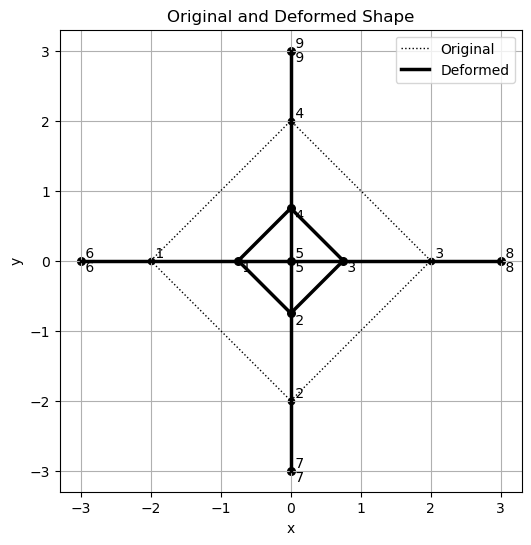

In [19]:
plot_original_and_deformed_shape_2d(elements, nodes, nodes_new)